In [1]:
# --- 0. IMPORTS ---
import pandas as pd
import scanpy as sc
import anndata as ad
import os
import hdf5plugin 
import numpy as np

main_path = r"Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis"
os.chdir(main_path)

adata = sc.read_h5ad("sce_data.h5ad")

adata

AnnData object with n_obs × n_vars = 223977 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types'
    obsm: 'X_umap'

In [ ]:
# Make a clean copy of counts (too much duplication for this)
#adata.layers["counts"] = adata.X.copy()

# --- Post-merging Analysis (Re-run embeddings on combined data) ---
# Now we must re-run normalization, as adata.X contains raw counts.
print("\n**Re-running Normalization and Analysis** on combined raw data...")

# 3.1 Re-Normalize and Log-Transform
# This overwrites adata.X with the normalized, log-transformed data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="batch_id")# Flavor seurat

# 4. PCA (Step 7)
# Use 'highly_variable' genes determined during initial per-sample QC
npca = 50

use_hvg = adata.var['highly_variable'].sum() > 0
if adata.n_obs > 20000:
    print(f"PCA analysis in chunks of 10000 cells (n_comps={npca})...")
    sc.tl.pca(adata, n_comps=npca, mask_var="highly_variable", chunked=True, chunk_size=10000, svd_solver="arpack")
else:
    print(f"PCA analysis (n_comps={npca})...")
    sc.tl.pca(adata, n_comps=npca, mask_var="highly_variable", chunked=False, svd_solver="arpack")
 
 # --- Custom Parameters ---
ndim = 2           # Number of UMAP dimensions
n_neighbors = 15   # Number of neighbors for the graph
my_res = 1.0       # Clustering resolution (changed from 2.0 to 1.0 as requested)
algo_cluster = "leidenalg"

# 5. Neighbors and UMAP (Step 8)
# This step uses the 50-component PCA result (adata.obsm['X_pca'])
print(f"Computing nearest neighbors (k={n_neighbors}) and UMAP (n_dims={ndim})...")
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=npca)
sc.tl.umap(adata, n_components=ndim)

# 6. Global Leiden Clustering (Replacing Batch-Aware Clustering)
# This runs Leiden once on the entire graph structure computed from the 50 PCs.
cluster_key = f'leiden_global_{my_res}' # Renamed key to reflect global clustering
print(f"\nComputing **Global** Leiden clusters (res={my_res}, flavor={algo_cluster}) on all {adata.n_obs} cells...")

sc.tl.leiden(
    adata,
    flavor=algo_cluster,
    n_iterations=2, # Use n_iterations=2 as in the previous code
    resolution=my_res,
    key_added=cluster_key
)



**Re-running Normalization and Analysis** on combined raw data...
PCA analysis in chunks of 10000 cells (n_comps=50)...
Computing nearest neighbors (k=15) and UMAP (n_dims=2)...

Computing **Global** Leiden clusters (res=1.0, flavor=leidenalg) on all 223977 cells...


Global Leiden clustering complete. Results in adata.obs['leiden_global_1.0']

Plotting UMAP colored by leiden_global_1.0 and saving...


[<Axes: title={'center': 'leiden_global_1.0'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'broad_cell_types'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'sub_cell_types'}, xlabel='UMAP1', ylabel='UMAP2'>]

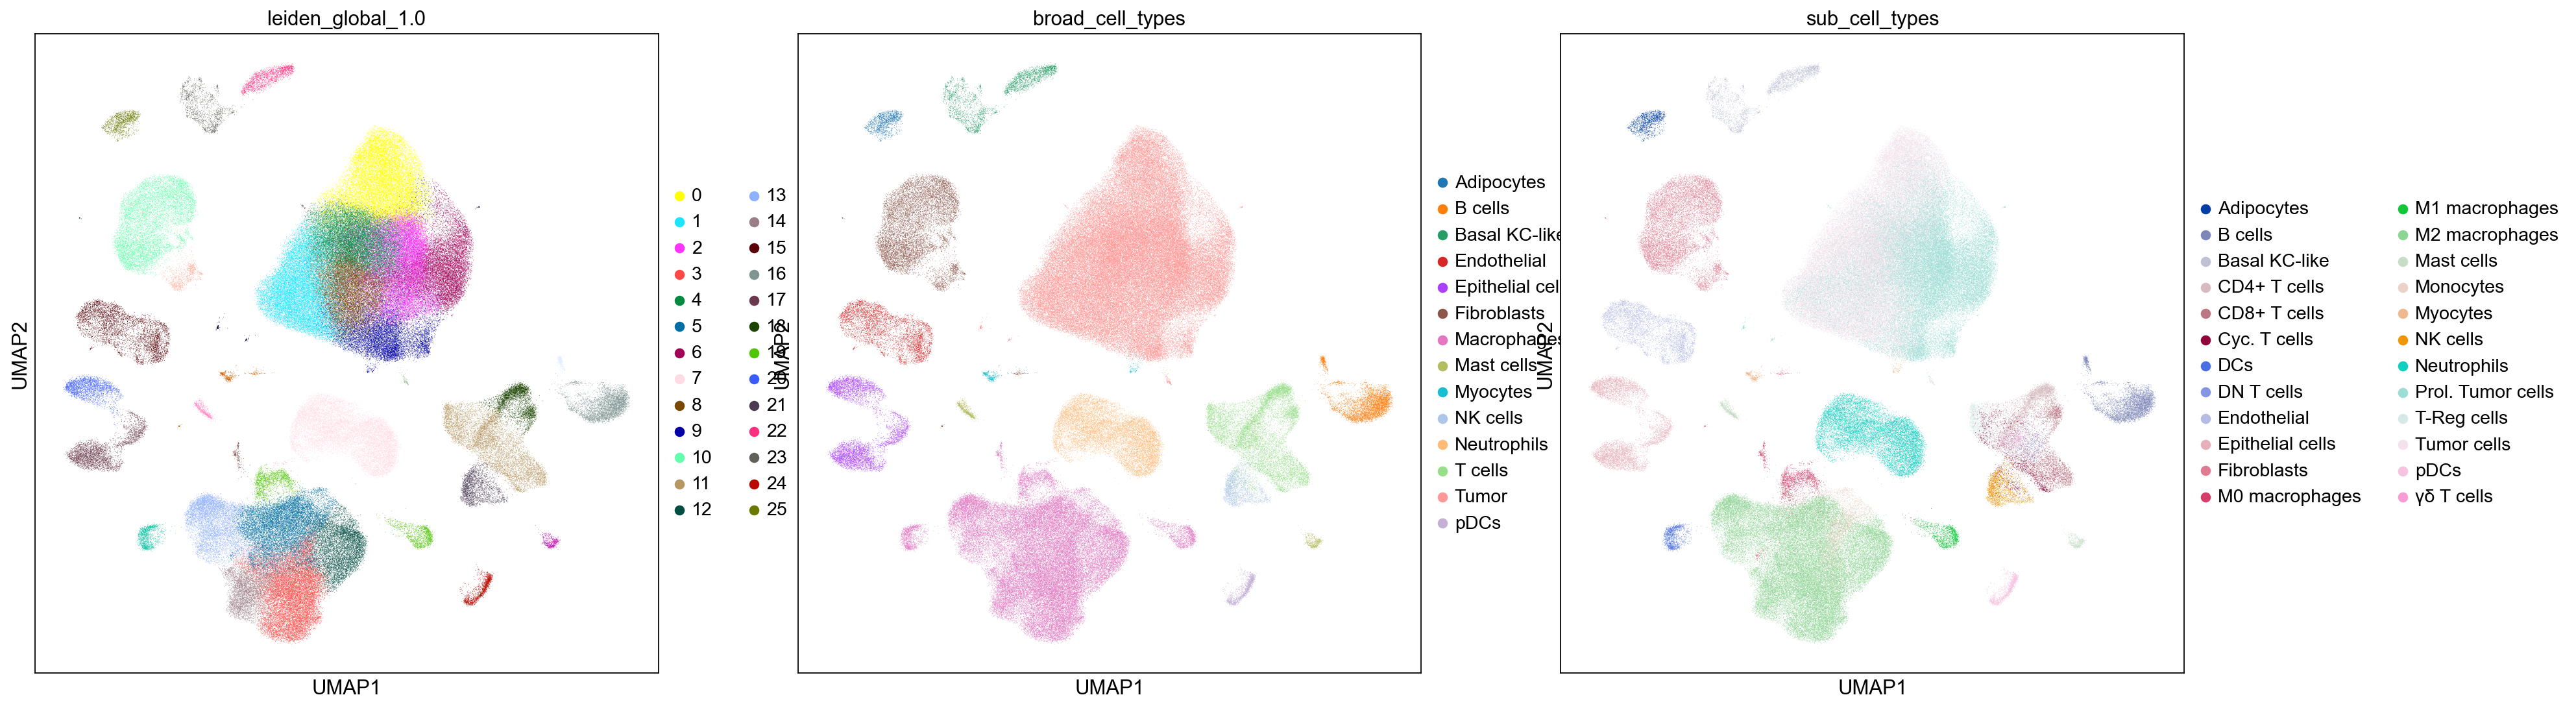

In [5]:
print(f"Global Leiden clustering complete. Results in adata.obs['{cluster_key}']")

# 7. Plot and Save UMAP
print(f"\nPlotting UMAP colored by {cluster_key} and saving...")
sc.set_figure_params(figsize=(8, 8)) 
sc.pl.umap(adata, color=[cluster_key, 'broad_cell_types', 'sub_cell_types'], show=False)
# The final H5AD save (Step 8) will automatically include all new results.

In [5]:
FILE_NAME = 'sato_mouse_breast_cancer_circadian.h5ad'
print(f"\nSaving final merged and processed AnnData to {FILE_NAME}")
#fname_sc = os.path.join(ROOT_ANALYSIS_PATH, FILE_NAME)
fname_sc = FILE_NAME
adata.write_h5ad( fname_sc, compression=hdf5plugin.FILTERS["zstd"] )


Saving final merged and processed AnnData to sato_mouse_breast_cancer_circadian.h5ad


In [ ]:
import scanpy as sc
import anndata as ad
import hdf5plugin
import os
import numpy as np
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Configuration ---
main_path = r"Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis"
os.chdir(main_path)
print(f"Current Working Directory set to: {os.getcwd()}")

# File names (now relative to CWD)
FILE_NAME = 'sato_mouse_breast_cancer_circadian.h5ad'
fname_filtered = FILE_NAME
adata = sc.read_h5ad(fname_filtered)


Current Working Directory set to: Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis


AnnData object with n_obs × n_vars = 11996 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types', 'leiden_global_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'broad_cell_types_colors', 'hvg', 'leiden_global_1.0', 'leiden_global_1.0_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_types_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [2]:
idx = adata.obs['broad_cell_types'] == "T cells"
adata = adata[idx,:].copy()
adata

AnnData object with n_obs × n_vars = 11996 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types'
    obsm: 'X_umap'

In [3]:
FILE_NAME = 'sato_mouse_breast_cancer_circadian_tcells_only.h5ad'
print(f"\nSaving final merged and processed AnnData to {FILE_NAME}")
#fname_sc = os.path.join(ROOT_ANALYSIS_PATH, FILE_NAME)
fname_sc = FILE_NAME
adata.write_h5ad( fname_sc, compression=hdf5plugin.FILTERS["zstd"] )


Saving final merged and processed AnnData to sato_mouse_breast_cancer_circadian_tcells_only_raw.h5ad


In [1]:
import scanpy as sc
import anndata as ad
import hdf5plugin
import os
import numpy as np
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Configuration ---
main_path = r"Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis"
os.chdir(main_path)
print(f"Current Working Directory set to: {os.getcwd()}")

# File names (now relative to CWD)
FILE_NAME = 'sato_mouse_breast_cancer_circadian_tcells_only.h5ad'
fname_filtered = FILE_NAME
adata = sc.read_h5ad(fname_filtered)
adata

Current Working Directory set to: Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis


AnnData object with n_obs × n_vars = 11996 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types', 'leiden_global_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'broad_cell_types_colors', 'hvg', 'leiden_global_1.0', 'leiden_global_1.0_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_types_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [2]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="batch_id")# Flavor seurat
#sc.pl.highly_variable_genes(adata, save="_hvgs_mean_disper.svg")
npca = 50

use_hvg = adata.var['highly_variable'].sum() > 0
if adata.n_obs > 20000:
    print(f"PCA analysis in chunks of 10000 cells (n_comps={npca})...")
    sc.tl.pca(adata, n_comps=npca, mask_var="highly_variable", chunked=True, chunk_size=10000, svd_solver="arpack")
else:
    print(f"PCA analysis (n_comps={npca})...")
    sc.tl.pca(adata, n_comps=npca, mask_var="highly_variable", chunked=False, svd_solver="arpack")


PCA analysis (n_comps=50)...


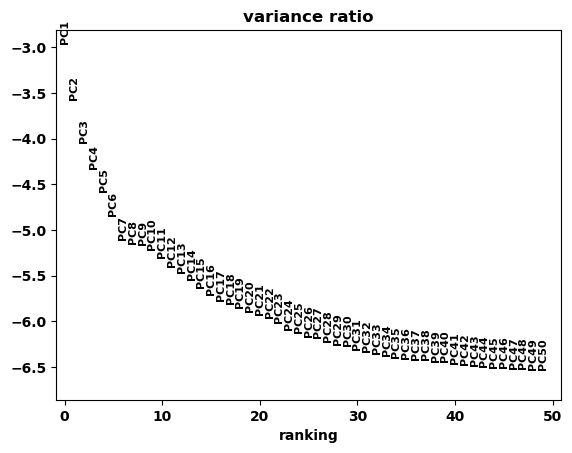

In [3]:
sc.pl.pca_variance_ratio(adata, n_pcs=npca, log=True)


Plotting UMAP colored by leiden_global_1.0 and saving...


[<Axes: title={'center': 'leiden_global_1.0'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'sub_cell_types'}, xlabel='UMAP1', ylabel='UMAP2'>]

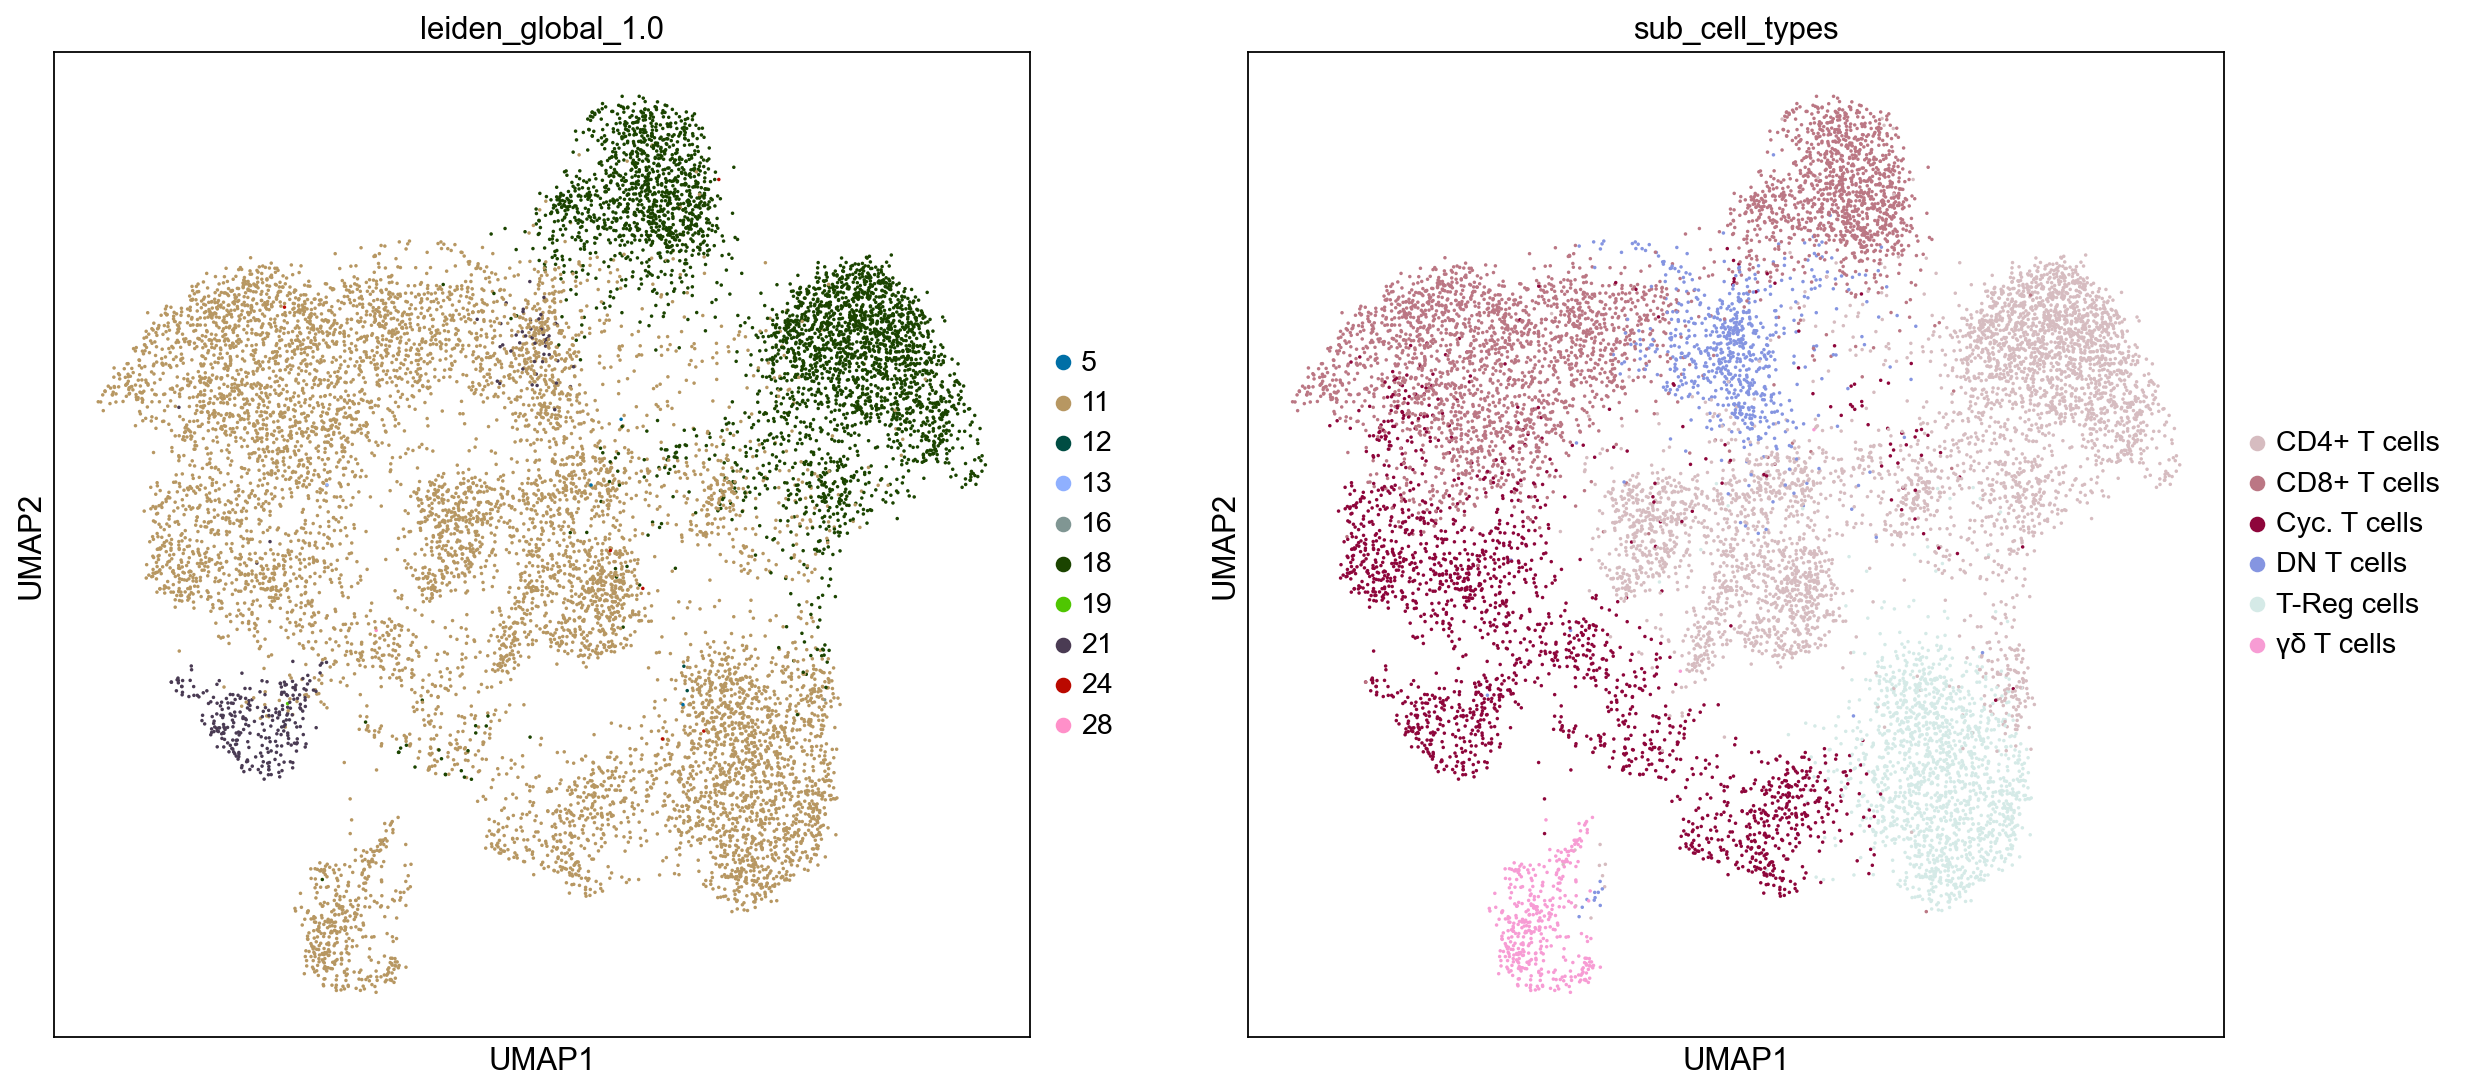

In [4]:
# --- Custom Parameters ---
ndim = 2           # Number of UMAP dimensions
n_neighbors = 15   # Number of neighbors for the graph
my_res = 1.0       # Clustering resolution (changed from 2.0 to 1.0 as requested)
algo_cluster = "leidenalg"

# 5. Neighbors and UMAP (Step 8)
# This step uses the 50-component PCA result (adata.obsm['X_pca'])
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=npca)
sc.tl.umap(adata, n_components=ndim)

# 6. Global Leiden Clustering (Replacing Batch-Aware Clustering)
cluster_key = f'leiden_global_{my_res}' # Renamed key to reflect global clustering

# 7. Plot and Save UMAP
print(f"\nPlotting UMAP colored by {cluster_key} and saving...")
sc.set_figure_params(figsize=(8, 8)) 
sc.pl.umap(adata, color=[cluster_key, 'sub_cell_types'], show=False)
# The final H5AD save (Step 8) will automatically include all new results.

In [5]:
adata.obs['tumor_stage'].unique()

['Intermediate', 'Early', 'Advanced']
Categories (3, object): ['Advanced', 'Early', 'Intermediate']

In [6]:
import pandas as pd
import numpy as np
import scanpy as sc
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Data Preparation: Ensure 'adata' is loaded and ready ---
def prepare_gene_expression_data(adata, min_cells_frac=0.1):
    """
    Extracts the gene expression matrix from the AnnData object and
    converts it into a pandas DataFrame (genes x cells).
    Filters for genes expressed in at least min_cells_frac fraction of cells.
    """
    # Convert to dense matrix if needed
    if hasattr(adata.X, 'toarray'):
        gene_expression_matrix = adata.X.T.toarray()
    else:  # assuming it's already a dense numpy array
        gene_expression_matrix = adata.X.T

    # Create DataFrame (Genes as index, Cells as columns)
    gene_expression_df = pd.DataFrame(
        gene_expression_matrix,
        index=adata.var_names,
        columns=adata.obs_names
    )

    # Filter genes: keep those expressed in at least min_cells_frac of cells
    # (expression > 0)
    cell_count = gene_expression_df.shape[1]
    min_cells = int(np.ceil(min_cells_frac * cell_count))

    # Sum across columns (cells), get how many cells each gene is expressed in
    expressed_in_cells = (gene_expression_df > 0).sum(axis=1)

    # Filter
    filtered_gene_expression_df = gene_expression_df.loc[expressed_in_cells >= min_cells]

    print(f"Filtered genes from {gene_expression_df.shape[0]} to {filtered_gene_expression_df.shape[0]}")
    return filtered_gene_expression_df

# --- 2. Correlation and Adjacency Matrix Calculation ---
def calculate_correlation_and_adjacency(gene_expression_df, method, threshold=0.5):
    """
    Calculates the gene-gene correlation matrix and an adjacency matrix
    based on a given absolute correlation threshold.
    methods ----> 'pearson', 'kendall', 'spearman' (str)
    """
    # Calculate the correlation matrix (Cells as rows, Genes as columns for correlation)
    # df.T ensures we correlate genes across cells
    corr_matrix = gene_expression_df.T.corr(method=method)

    # Filter for strong correlations to create the adjacency matrix.
    adj_matrix = np.where(np.abs(corr_matrix.values) > threshold, corr_matrix.values, 0)
    # Remove self-loops (correlation of a gene with itself)
    np.fill_diagonal(adj_matrix, 0)
    non_zero_count = np.count_nonzero(adj_matrix)
    print(f"Number of non-zero elements (connections): {non_zero_count}")
    
    return corr_matrix.index, adj_matrix

def calculate_correlation_and_adjacency_top_percent(gene_expression_df, method, top_percent=0.05):
    """
    Calculates the gene-gene correlation matrix and an adjacency matrix,
    keeping only the top_percent strongest (absolute-value) links.
    """
    corr_matrix = gene_expression_df.T.corr(method=method)
    abs_corr = np.abs(corr_matrix.values)

    # Flatten, sort, get the cutoff
    all_corrs = abs_corr.flatten()
    valid_corrs = all_corrs[all_corrs != 1]    # Exclude diagonal/self-correlation
    cutoff = np.percentile(valid_corrs, 100*(1-top_percent))

    adj_matrix = np.where(abs_corr > cutoff, corr_matrix.values, 0)
    np.fill_diagonal(adj_matrix, 0)

    non_zero_count = np.count_nonzero(adj_matrix)
    print(f"Threshold for top {int(top_percent*100)}% links: {cutoff:.3f}")
    print(f"Number of top edges retained: {non_zero_count}")

    return corr_matrix.index, adj_matrix

# --- 3. Network Graph Construction and Plotting Function (UPDATED) ---
def plot_correlation_network(adj_matrix, gene_names, title_suffix, num_nodes=20, figsize=(6, 5), filename=None):
    """
    Constructs a NetworkX graph, extracts a sub-network, plots the result,
    and optionally saves the figure.
    
    Args:
        adj_matrix (np.ndarray): The gene-gene adjacency matrix.
        gene_names (pd.Index): The list of gene names.
        title_suffix (str): The correlation method (e.g., 'Pearson').
        num_nodes (int): The number of top-connected genes to plot.
        figsize (tuple): The size of the output figure (width, height).
        filename (str, optional): Filename to save the plot (e.g., 'pearson_network.png'). 
                                   If None, the figure is only displayed.
    """
    # Create a graph object from the adjacency matrix
    G = nx.from_numpy_array(adj_matrix)

    # Map the integer indices back to gene names
    mapping = {i: gene_names[i] for i in range(len(gene_names))}
    G = nx.relabel_nodes(G, mapping)

    # Remove nodes that have no connections (isolated genes)
    G.remove_nodes_from(list(nx.isolates(G)))

    # Find the top 'num_nodes' most highly connected genes
    degrees = dict(G.degree())
    most_connected_genes = sorted(degrees, key=degrees.get, reverse=True)[:num_nodes]
    subgraph = G.subgraph(most_connected_genes)

    # Set a layout for visualization
    subgraph_pos = nx.fruchterman_reingold_layout(subgraph, seed=42)

    # Plotting: Figure size is now an argument input
    plt.figure(figsize=figsize)
    nx.draw(subgraph,
            pos=subgraph_pos,
            with_labels=True,
            node_size=300,# INCREASE THIS VALUE to make nodes larger
            font_size=10,# INCREASE THIS VALUE to make gene labels larger
            font_color='black',
            node_color='skyblue',
            edge_color='gray',
            width=0.5)
    
    plt.title(f"Gene Correlation Network ({title_suffix}): Top {len(subgraph.nodes)} Genes", fontsize=10)

    # Save the file if a filename is provided (New Feature)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved figure to {filename}")

    plt.show()

In [7]:
idx = adata.obs['sub_cell_types'] == "CD8+ T cells"
adata_cd8_tcells = adata[idx, :].copy()
adata_cd8_tcells

AnnData object with n_obs × n_vars = 3267 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types', 'leiden_global_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'broad_cell_types_colors', 'hvg', 'leiden_global_1.0', 'leiden_global_1.0_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_types_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
cancer_stages = adata_cd8_tcells.obs['tumor_stage'].unique()
# GRN from co-expressions
method = 'pearson'
for istage in cancer_stages:
    print(f"Processing stage: {istage}")
    idx = adata_cd8_tcells.obs['tumor_stage'] == istage
    adata_cd8_tcells_istage = adata_cd8_tcells[idx, :].copy()
    
    gene_expression_df = prepare_gene_expression_data(adata_cd8_tcells_istage, min_cells_frac=0.1)
    
    #gene_names, adj_matrix = calculate_correlation_and_adjacency(gene_expression_df, method, threshold=0.5)
    gene_names, adj_matrix = calculate_correlation_and_adjacency_top_percent(gene_expression_df, method="pearson", top_percent=0.05)
    
    title_suffix = f"{method.capitalize()} - {istage}"
    plot_correlation_network(adj_matrix, gene_names, title_suffix, num_nodes=10, figsize=(6, 5) )

Processing stage: Intermediate


NameError: name 'prepare_gene_expresssion_data' is not defined

In [9]:
import pandas as pd
import numpy as np
from arboreto.algo import grnboost2
from arboreto.utils import load_tf_names
from dask.distributed import Client
import psutil

# ---- Dask client: physical cores minus 2 ----
n_cores = max(psutil.cpu_count(logical=False) - 2, 1)
client = Client(n_workers=n_cores, threads_per_worker=1, processes=True)
print(f"Using {n_cores} Dask workers/procs (out of {psutil.cpu_count(logical=False)})")

# ---- Load TFs (mouse) ----
tf_names = load_tf_names('allTFs_mm.txt')  # TF list (one gene symbol per line)

def prepare_gene_expression_data2(adata, min_cells_frac=0.1):
    if hasattr(adata.X, "toarray"):
        m = adata.X.T.toarray()
    else:
        m = adata.X.T
    df = pd.DataFrame(m, index=adata.var_names, columns=adata.obs_names)
    n_cells = df.shape[1]
    min_cells = int(np.ceil(min_cells_frac * n_cells))
    df = df.loc[(df > 0).sum(axis=1) >= min_cells]
    return df

# ---- Compute GRNBoost2 networks for each stage ----
networks = {}  # Save each stage's network DataFrame

for istage in adata_cd8_tcells.obs['tumor_stage'].unique():
    print(f"\nProcessing stage: {istage}")
    idx = adata_cd8_tcells.obs['tumor_stage'] == istage
    adata_stage = adata_cd8_tcells[idx, :].copy()
    gene_expression_df = prepare_gene_expression_data2(adata_stage, min_cells_frac=0.1)

    # Make sure all TFs are present as rows (add zeroes if missing)
    tf_in_data = set(tf_names) & set(gene_expression_df.index)
    missing_tfs = set(tf_names) - tf_in_data
    for tf in missing_tfs:
        gene_expression_df.loc[tf] = 0

    # cells x genes
    ex_matrix = gene_expression_df.T
    ex_matrix = ex_matrix.loc[:, ~ex_matrix.columns.duplicated()]
    ex_matrix = ex_matrix.fillna(0)
    ex_matrix.columns = ex_matrix.columns.astype(str)

    valid_tfs = [tf for tf in tf_names if tf in ex_matrix.columns]
    print("Shape of ex_matrix:", ex_matrix.shape)
    print("Number of TFs in matrix:", len(valid_tfs))
    if len(valid_tfs) == 0:
        print("No valid TFs for this stage, skipping.")
        continue

    # ---- Run GRNBoost2 and store in dict ----
    network = grnboost2(
        expression_data=ex_matrix,
        tf_names=valid_tfs,
        gene_names=list(ex_matrix.columns),
        client_or_address=client
    )
    print("Top edges:")
    print(network.sort_values('importance', ascending=False).head(10))
    networks[istage] = network  # Save for later

print("\nAll networks computed and stored in networks{}.")


Using 12 Dask workers/procs (out of 14)

Processing stage: Intermediate
Shape of ex_matrix: (1342, 7904)
Number of TFs in matrix: 1860


c:\Local_install\miniconda3\envs\pyscenic\lib\site-packages\distributed\client.py:3163: UserWarning: Sending large graph of size 72.17 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Top edges:
        TF target  importance
396   Tcf7   Klf2   20.084554
295   Klf2   Sell   16.737715
397   Tcf7    Id2   16.643621
295   Klf2    Id2   15.852309
442    Id2   Sell   15.175844
295   Klf2   Tcf7   14.784361
441    Id2   Klf2   12.951381
397   Tcf7   Sell   12.497781
106   Lef1   Sell   11.020770
575  Runx2   Sell   10.508874

Processing stage: Early
Shape of ex_matrix: (748, 7241)
Number of TFs in matrix: 1860


c:\Local_install\miniconda3\envs\pyscenic\lib\site-packages\distributed\client.py:3163: UserWarning: Sending large graph of size 37.10 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:

# ---- Post-processing: plotting or saving ----
import networkx as nx
import matplotlib.pyplot as plt

for istage, network in networks.items():
    top_edges = network.sort_values('importance', ascending=False).head(50)
    G = nx.from_pandas_edgelist(top_edges, 'regulator', 'target', edge_attr='importance', create_using=nx.DiGraph())
    plt.figure(figsize=(10,8))
    pos = nx.spring_layout(G, k=0.3, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=100, arrows=True, font_size=8)
    plt.title(f"GRNBoost2 ({istage}) Top 50 Edges")
    plt.show()
    # Optionally save:
    # network.to_csv(f"network_edges_{istage}.csv", index=False)

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.optimize import curve_fit
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from joblib import Parallel, delayed
import time
import warnings
import scipy.sparse # Necessary for type checking

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ==============================================================================
# Helper Functions for Circadian Fitting
# ==============================================================================

def estimate_phase_r(Xg_zts, time_step, period=24, test_type='Ftest'):
    """Estimates phase, amplitude, etc., from gene expression data (single gene)."""
    icells = [len(x) for x in Xg_zts]
    R = np.concatenate(Xg_zts)
    num_cells = sum(icells)
    if num_cells < 4 or np.sum([np.mean(x) if len(x) > 0 else 0 for x in Xg_zts]) == 0:
        return np.nan, np.nan, period, np.nan, np.nan, np.nan, np.nan
        
    time_grid = np.repeat(np.arange(len(Xg_zts)) * time_step, icells)
    R0 = np.array([np.mean(x) if len(x) > 0 else 0 for x in Xg_zts])
    
    def cos_model(t, acro, amp, mesor):
        return amp * np.cos(2 * np.pi * (t - acro) / period) + mesor
        
    mean_model_val = np.mean(R)
    max_amp_guess = np.max(R0) - mean_model_val
    max_peak_t_guess = (np.argmax(R0)) * time_step
    
    p0 = [max_peak_t_guess, max_amp_guess, mean_model_val]
    bounds = ([0, -np.inf, 0], [period, np.inf, np.inf])

    try:
        popt, _ = curve_fit(cos_model, time_grid, R, p0=p0, bounds=bounds, maxfev=5000)
        acrophase, amp, mesor = popt
        
        SSR_null = np.sum((R - mean_model_val)**2)
        SSR_sine = np.sum((R - cos_model(time_grid, *popt))**2)
        
        if SSR_sine == 0 or len(R) <= 3: 
            p_value = np.nan
        else:
            if test_type == 'Ftest':
                d1, d2 = 2, len(R) - 3
                F_stat = ((SSR_null - SSR_sine) / d1) / (SSR_sine / d2)
                p_value = 1 - stats.f.cdf(F_stat, d1, d2)
            else: # LRT
                n = num_cells
                logL_null = -0.5 * n * (np.log(2 * np.pi * (SSR_null / n)) + 1)
                logL_sine = -0.5 * n * (np.log(2 * np.pi * (SSR_sine / n)) + 1)
                LRT_stat = -2 * (logL_null - logL_sine)
                p_value = 1 - stats.chi2.cdf(LRT_stat, df=2)
            
        t_pts = np.arange(len(Xg_zts)) * time_step
        fval = cos_model(t_pts, acrophase, amp, mesor)
        rho, p_value_rho = stats.pearsonr(R0, fval) if np.std(R0) > 0 and np.std(fval) > 0 else (np.nan, np.nan)
            
    except (RuntimeError, ValueError):
        return np.nan, np.nan, period, np.nan, np.nan, np.nan, np.nan
        
    return acrophase, amp, period, mesor, p_value, rho, p_value_rho

def _process_gene_optimized(gene_expr_vector, time_masks, time_step, period, test_type='Ftest'):
    """Worker function for parallel processing (joblib)."""
    Xg_zts = [gene_expr_vector[mask] for mask in time_masks]
    R0 = [np.mean(x) if len(x) > 0 else np.nan for x in Xg_zts]
    results = estimate_phase_r(Xg_zts, time_step, period=period, test_type=test_type)
    return list(results) + R0 

# ==============================================================================
# 🧠 Main Analysis Function (sce_circ_phase_estimation)
# ==============================================================================

def sce_circ_phase_estimation(
    adata, tmeta, ct_layer,
    batch_obs_key='ZT_time', 
    rm_low_conf=True, period=24,
    custom_genelist=None, custom_celltype=None,
    norm_str='lib_size', # Retained default based on typical scRNA-seq pipeline
    n_jobs=-1
):
    """Performs circadian phase estimation on an AnnData object."""
    start_time = time.time()

    tmeta = tmeta.sort_values('times').reset_index(drop=True)
    time_step = np.mean(np.diff(tmeta.times.unique()))
    
    if norm_str == 'lib_size':
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
    elif norm_str is None:
         print("Using provided data (adata.X). Skipping normalization.")
        
    all_cell_types = sorted(adata.obs[ct_layer].unique())
    cell_type_list = [ct for ct in (custom_celltype or all_cell_types) if ct in all_cell_types]
        
    for cell_type in cell_type_list:
        print(f"\nProcessing cell type: {cell_type}")
        
        cell_type_mask = adata.obs[ct_layer] == cell_type

        # None OR 'all' explicitly
        if custom_genelist is None or custom_genelist == 'all':
            gene_list = adata.var_names.tolist() # Use all genes
        else:
            # Check for specific list, filtering against genes present in adata
            gene_list = [g for g in custom_genelist if g in adata.var_names]
            
        #print(f"\nNumber of genes to analyze: {len(gene_list)}")
        if not gene_list: continue
            
        batch_time_labels = sorted(tmeta['old_labels'].unique()) 
        
        # --- Step 3: Prepare data for efficient parallel processing ---
        
        time_masks = []
        for zt_label in batch_time_labels:
            # Mask checks the cell type mask AND the ZT_time label
            mask = (cell_type_mask) & (adata.obs[batch_obs_key] == zt_label)
            time_masks.append(mask[cell_type_mask].values) 
            
        if not any(np.any(m) for m in time_masks):
            print(f"Warning: No cells found in any ZT group for {cell_type}. Skipping.")
            continue

        X_subset = adata[cell_type_mask, gene_list].X
        if isinstance(X_subset, (scipy.sparse.spmatrix, np.matrix)):
            X_subset = X_subset.toarray()

        results = Parallel(n_jobs=n_jobs)(
            delayed(_process_gene_optimized)(X_subset[:, i], time_masks, time_step, period)
            for i in range(len(gene_list))
        )
        
        # --- Step 4: Aggregate, Post-process, and Save ---
        col_names_T1 = ["Acrophase", "Amp", "Period", "Mesor", "pvalue", "Sine_corr", "pvalue_corr"]
        T1 = pd.DataFrame([res[:7] for res in results], columns=col_names_T1)
        T2 = pd.DataFrame([res[7:] for res in results], columns=batch_time_labels)
        T1['Genes'] = gene_list; T2['Genes'] = gene_list
        
        T1 = T1.dropna(subset=['pvalue', 'pvalue_corr']).reset_index(drop=True)
        T2 = T2[T2['Genes'].isin(T1['Genes'])].reset_index(drop=True)

        if T1.empty: continue

        T1['Abs_Amp'] = T1['Amp'].abs()
        T1['Acrophase_24'] = T1['Acrophase'].apply(lambda x: (x % 24) if not pd.isna(x) else x)
        
        # **CORRECTION IMPLEMENTED**: Fix the fdrcorrection TypeError
        reject, T1['pvalue_adj'] = fdrcorrection(T1['pvalue'])
        reject_corr, T1['pvalue_adj_corr'] = fdrcorrection(T1['pvalue_corr'])
        
        T1 = T1[["Genes", "Amp", "Abs_Amp", "Mesor", "Acrophase", "Acrophase_24", "Period", 
                 "pvalue", "pvalue_adj", "Sine_corr", "pvalue_corr", "pvalue_adj_corr"]]
        
        confident_mask = (T1.pvalue < 0.05) & (T1.pvalue_corr < 0.05)
        T1_filtered = T1[confident_mask].copy() if rm_low_conf else T1.copy()
        T2_filtered = T2[T2['Genes'].isin(T1_filtered['Genes'])].copy()

        T1_filtered = T1_filtered.sort_values(
            by=["pvalue_adj_corr", "pvalue_adj", "Acrophase_24", "Abs_Amp"], ascending=[True, True, True, False]
        ).reset_index(drop=True)
        T2_filtered = T2_filtered.set_index('Genes').loc[T1_filtered['Genes']].reset_index()

        fname_prefix = f"{cell_type}_period_{period}"
        T1_filtered.to_csv(f"{fname_prefix}_macro_circadian_analysis.csv", index=False)
        T2_filtered.to_csv(f"{fname_prefix}_macro_circadian_ZTs.csv", index=False)
        
        T3 = T2_filtered.set_index('Genes').copy()
        zt_cols = T3.columns
        R0_norm = T3[zt_cols].div(T3[zt_cols].values.min(axis=1)[:, np.newaxis], axis=0)
        T3_normalized = R0_norm.reset_index()
        T3_normalized.to_csv(f"{fname_prefix}_macro_circadian_ZTs_normalized.csv", index=False)


    total_time = time.time() - start_time
    print(f"\nProcessing complete. Total time elapsed: {total_time:.2f} seconds")
    return T1_filtered, T2_filtered 



In [93]:
# ==============================================================================
# 🚀 MAIN EXECUTION BLOCK (FINAL)
# ==============================================================================

# --- ASSUMPTION: Your AnnData object 'adata' is loaded here. ---
# For instance: adata = sc.read_h5ad("your_data_file.h5ad")

# --- 1. Define Metadata and Circadian Genes ---

# Define tmeta table to link ZT labels to numeric times
unique_zt = sorted(adata.obs['ZT_time'].unique())

# --- 2. Time Point Conversion (Must be done first to populate 'time_numeric') ---
print("\n--- Performing ZT time conversion ---")
zt_series = adata.obs['ZT_time']
numeric_times = zt_series.str.replace('ZT', '').astype('Int64')
# Populate the 'time_numeric' column needed for the tmeta creation logic
adata.obs['time_numeric'] = numeric_times
print(f"Added 'time_numeric' column. Example: ZT_time='{zt_series.iloc[0]}', time_numeric={numeric_times.iloc[0]}")


# Create a mapping for numeric times based on ZT label to handle potential unsorted unique() outputs
zt_time_map = adata.obs.drop_duplicates(subset='ZT_time').set_index('ZT_time')['time_numeric'].reindex(unique_zt)

tmeta = pd.DataFrame({
    'old_labels': unique_zt,  # The key used in adata.obs ('ZT00', 'ZT03', etc.)
    'new_labels': unique_zt,   # The label used in output columns
    'times': zt_time_map.values
}).sort_values('times').reset_index(drop=True)


classic_circ = ["arnt", "bhlh", "clock", "cry", "dbp", "tef", "hlf", "raf", "erk", 
                 "mek", "ras", "mtor", "map", "ral", "akt", "hif", "kras", "myc", 
                 "nfkb", "per", "wnt", "nr1d", "rev", "pik", "ror"]

# circ_genes is deliberately set to None in the execution block below to analyze all genes
circ_genes = [g for g in adata.var_names if any(g.lower().startswith(c) for c in classic_circ)]

# Analysis settings
output_folder = "sub_pops_circadian_genes"
cell_stage_key = 'tumor_stage' # Key to subset by (e.g., 'tumor_stage', 'treatment')
ct_layer = 'sub_cell_types' 
rm_low_conf = True
original_dir = os.getcwd()

# --- 3. Main Loop Over Stages ---

print("\n--- Starting Main Analysis Loop over Stages ---")
unique_cell_stages = adata.obs[cell_stage_key].unique()

for istage in unique_cell_stages:
    stage_fname = f"stage_{istage}_{output_folder}".replace(' ', '_').replace('/', '_')
    
    if not os.path.exists(stage_fname):
        os.makedirs(stage_fname)
    os.chdir(stage_fname)
    
    print(f"\n--- Processing Stage: {istage} in {stage_fname} ---")
    
    try:
        idx_stage = adata.obs[cell_stage_key] == istage
        adata_sub_stage = adata[idx_stage, :].copy() 

        # Perform the analysis with the correct grouping key
        T1, T2 = sce_circ_phase_estimation(
            adata=adata_sub_stage, 
            tmeta=tmeta, 
            ct_layer=ct_layer,
            batch_obs_key='ZT_time', # Group cells by ZT label
            rm_low_conf=rm_low_conf, 
            period=24, 
            custom_genelist= 'all', # Passes 'all' to the function
            norm_str= None, # Reverted norm_str to default 'lib_size' for consistency
            n_jobs=-1
        )
        
        print(f"Successfully processed Stage {istage}. Results saved in {stage_fname}")

    except Exception as err:
        print(f"Error processing stage: {istage}")
        print(f"Error message: {err}")
    finally:
        os.chdir(original_dir)
        
print("\n--- All stages processed ---")


--- Performing ZT time conversion ---
Added 'time_numeric' column. Example: ZT_time='ZT06', time_numeric=6

--- Starting Main Analysis Loop over Stages ---

--- Processing Stage: Intermediate in stage_Intermediate_sub_pops_circadian_genes ---
Using provided data (adata.X). Skipping normalization.

Processing cell type: CD4+ T cells

Number of genes to analyze: 19000

Processing cell type: CD8+ T cells

Number of genes to analyze: 19000

Processing cell type: Cyc. T cells

Number of genes to analyze: 19000

Processing cell type: DN T cells

Number of genes to analyze: 19000

Processing cell type: T-Reg cells

Number of genes to analyze: 19000

Processing cell type: γδ T cells

Number of genes to analyze: 19000

Processing complete. Total time elapsed: 27.34 seconds
Successfully processed Stage Intermediate. Results saved in stage_Intermediate_sub_pops_circadian_genes

--- Processing Stage: Early in stage_Early_sub_pops_circadian_genes ---
Using provided data (adata.X). Skipping normali